# CT118-3-3 ODL — Assignment 2
## Deep Learning Model Building, Tuning & Evaluation
### Used-Car Price Prediction (Craigslist Used Cars Dataset)




## Environment & Imports






In [1]:
import os, warnings, time, json
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # silence TF info/warning logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
keras = tf.keras
layers = tf.keras.layers
import keras_tuner as kt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)



## 1. Configuration & Load Cleaned Data



In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────
DATA_PATH    = os.path.join('dataset', 'vehicles_cleaned.csv')
SAMPLE_SIZE  = None        # None = full dataset; or e.g. 100_000 for fast dev
TUNER_TRIALS = 25          # Keras Tuner trials per model (assignment: ~25-30)
MAX_EPOCHS   = 60          # upper bound; EarlyStopping usually stops earlier
TUNE_EPOCHS  = 25          # shorter budget per tuning trial
BATCH_SIZE   = 512
TARGET       = 'price'

df = pd.read_csv(DATA_PATH)
if SAMPLE_SIZE is not None:
    df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=SEED).reset_index(drop=True)

# Check the file matches the current data_cleaning.ipynb. Without this an old cleaned CSV either
# fails silently (a feature is just missing) or crashes with a confusing KeyError further down.
REQUIRED = ['price', 'price_log', 'year', 'car_age', 'odometer',
            'cylinders_num', 'cylinders_unknown', 'model', 'manufacturer']
STALE    = ['description', 'posting_date', 'VIN', 'id', 'url', 'county']  # dropped in cleaning

missing = [c for c in REQUIRED if c not in df.columns]
stale   = [c for c in STALE    if c in df.columns]
if missing or stale:
    raise ValueError(
        f'{DATA_PATH} does not match the current data_cleaning.ipynb.\n'
        f'  missing columns                       : {missing}\n'
        f'  columns that should have been dropped : {stale}\n'
        f'Re-run data_cleaning.ipynb to regenerate the file.')

print(f'Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} cols   (schema OK)')
print(f'Columns: {list(df.columns)}')
df.head(3)

Loaded cleaned dataset: 201,019 rows x 18 cols   (schema OK)
Columns: ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state', 'cylinders_num', 'cylinders_unknown', 'car_age', 'price_log']


,region,price,year,manufacturer,model,condition,fuel,odometer,title_status,transmission,drive,type,paint_color,state,cylinders_num,cylinders_unknown,car_age,price_log
0,auburn,33590,2014,gmc,other,good,gas,57923.0,clean,other,unknown,pickup,white,al,8.0,0,7,10.422013
1,auburn,22590,2010,chevrolet,silverado 1500,good,gas,71229.0,clean,other,unknown,pickup,blue,al,8.0,0,11,10.025307
2,auburn,39590,2020,chevrolet,other,good,gas,19160.0,clean,other,unknown,pickup,red,al,8.0,0,1,10.586357


## 2. Feature Engineering & Selection

Most of the preparation is already done in `data_cleaning.ipynb`, so these columns are used exactly
as they arrive:

- **`car_age`** = `scrape_year - year`. It cannot be rebuilt here because `posting_date` is dropped
  upstream, and using the current year instead would add the same few years to every car.
- **`price_log`** = `log1p(price)`, the training target. Price is still skewed after the \$57,364
  cap, and every prediction goes back through `expm1` before any metric is calculated.
- **`cylinders_num` / `cylinders_unknown`** — engine size as a number, plus a flag for the rows
  where it was missing and had to be median filled.
- **`model`** — already normalised and cut down to the top 500 names plus `other`, so the embedding
  table is about 501 rows instead of 29,667.

What this notebook adds:

1. **`miles_per_year`** = `odometer / (car_age + 1)`, so the network can tell a hard-driven 3 year
   old car from a lightly used 10 year old one with the same odometer reading.
2. **Feature groups** — numeric (scaled) and categorical (embedded). `year` is left out because it
   is the same information as `car_age`, and `price` and `price_log` are left out because they are
   the target.

In [3]:
# car_age, price_log, cylinders_num and cylinders_unknown all come from data_cleaning.ipynb, so
# they are used as they are. car_age could not be rebuilt here anyway since posting_date is dropped.

# Usage per year, so the network can separate a hard-driven newer car from a lightly used older one.
df['miles_per_year'] = df['odometer'] / (df['car_age'] + 1)

# lat/long only exist if DROP_LATLONG was switched off in the cleaning notebook.
num_feats = [c for c in ['car_age', 'odometer', 'miles_per_year',
                         'cylinders_num', 'cylinders_unknown', 'lat', 'long']
             if c in df.columns]

# Everything non-numeric becomes an embedded category. year is dropped because it is the same
# information as car_age, and price/price_log are the target so they can never be inputs.
# select_dtypes is used instead of dtype == object so this also works on pandas 3.
exclude   = set(num_feats) | {TARGET, 'price_log', 'year'}
cat_feats = [c for c in df.select_dtypes(exclude=['number']).columns if c not in exclude]

print(f'Numeric features  ({len(num_feats)}): {num_feats}')
print(f'Categorical feats ({len(cat_feats)}): {cat_feats}')
print(f'Target            : price_log = log1p(price)  (from data_cleaning.ipynb)')

unused = [c for c in df.columns if c not in num_feats + cat_feats + [TARGET, 'price_log']]
print(f'Not used as features: {unused}')

print('\nCategorical cardinality before the train-only cap in Section 3:')
print(df[cat_feats].nunique().sort_values(ascending=False).to_string())

Numeric features  (5): ['car_age', 'odometer', 'miles_per_year', 'cylinders_num', 'cylinders_unknown']
Categorical feats (11): ['region', 'manufacturer', 'model', 'condition', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
Target            : price_log = log1p(price)  (from data_cleaning.ipynb)
Not used as features: ['year']

Categorical cardinality before the train-only cap in Section 3:
model           501
region          404
state            51
manufacturer     40
type             14
paint_color      13
condition         7
title_status      6
fuel              5
drive             4
transmission      3


### 2.1 Quick look at target skew (before vs after log-transform)
The log transform pulls in the long right tail, giving the network a better-conditioned
target to learn.

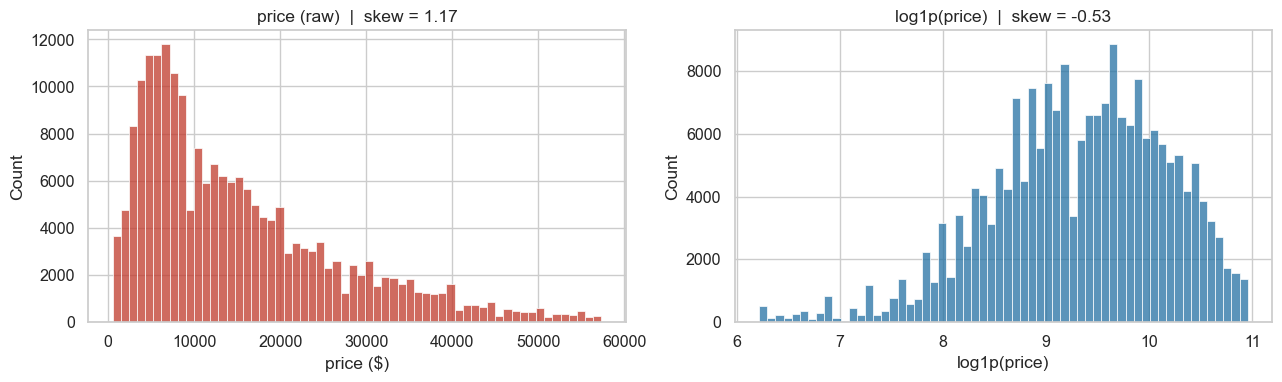

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET], bins=60, ax=axes[0], color='#c0392b')
axes[0].set_title(f'price (raw)  |  skew = {df[TARGET].skew():.2f}')
axes[0].set_xlabel('price ($)')
sns.histplot(df['price_log'], bins=60, ax=axes[1], color='#2471a3')
axes[1].set_title(f'log1p(price)  |  skew = {df["price_log"].skew():.2f}')
axes[1].set_xlabel('log1p(price)')
plt.tight_layout(); plt.show()

## 3. Train / Validation / Test Split & Encoding

A three-way split: **70% train** for the weights, **15% validation** for EarlyStopping and Keras
Tuner, and **15% test** that is never touched until the final numbers.



In [5]:
X = df[num_feats + cat_feats].copy()
y = df['price_log'].values          # target already log1p-transformed in data_cleaning.ipynb

# 70 / 15 / 15 split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED)

print(f'Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Cleaning already cut 'model' to the top 500 names, but it used the whole dataset to pick them.
# Redoing the cut on the training split only keeps the vocabulary honest, and anything left over
# goes into the same 'other' bucket cleaning uses, so there is one catch-all and not two.
MODEL_TOP_N = 300
OTHER_TOKEN = 'other'
if 'model' in cat_feats:
    top_models = X_train['model'].value_counts().nlargest(MODEL_TOP_N).index
    for split_df in (X_train, X_val, X_test):
        split_df['model'] = split_df['model'].where(
            split_df['model'].isin(top_models), OTHER_TOKEN)
    print(f"'model': {X['model'].nunique()} categories from cleaning -> top {MODEL_TOP_N} by "
          f"train frequency + '{OTHER_TOKEN}' -> {X_train['model'].nunique()} seen in train")

# Fit the scaler and encoder on the training split only
scaler = StandardScaler().fit(X_train[num_feats])
encoder = OrdinalEncoder(handle_unknown='use_encoded_value',
                         unknown_value=-1).fit(X_train[cat_feats])

def preprocess(Xframe):
    num = scaler.transform(Xframe[num_feats]).astype('float32')
    cat = (encoder.transform(Xframe[cat_feats]).astype('int64') + 1)  # +1 -> 0 reserved
    return num, cat

num_tr, cat_tr = preprocess(X_train)
num_val, cat_val = preprocess(X_val)
num_te, cat_te = preprocess(X_test)

# Embedding size for each categorical column (biggest code seen + 1)
cardinalities = [
    int(max(cat_tr[:, i].max(), cat_val[:, i].max(), cat_te[:, i].max())) + 1
    for i in range(len(cat_feats))
]
for c, card in zip(cat_feats, cardinalities):
    print(f'  {c:15s} -> embedding input dim {card}')

Train: 140,713 | Val: 30,153 | Test: 30,153
'model': 501 categories from cleaning -> top 300 by train frequency + 'other' -> 300 seen in train
  region          -> embedding input dim 404
  manufacturer    -> embedding input dim 41
  model           -> embedding input dim 301
  condition       -> embedding input dim 8
  fuel            -> embedding input dim 6
  title_status    -> embedding input dim 7
  transmission    -> embedding input dim 4
  drive           -> embedding input dim 5
  type            -> embedding input dim 15
  paint_color     -> embedding input dim 14
  state           -> embedding input dim 52


### 3.1 Pack inputs for multi-input Keras models
Both networks take **one numeric input tensor plus one integer tensor per categorical
column**. The helper below arranges each split into the list of arrays Keras expects.

In [6]:
def make_inputs(num, cat):
    '''Return [numeric_block, cat_col_0, cat_col_1, ...] for a multi-input model.'''
    return [num] + [cat[:, i] for i in range(cat.shape[1])]

train_inputs = make_inputs(num_tr, cat_tr)
val_inputs   = make_inputs(num_val, cat_val)
test_inputs  = make_inputs(num_te, cat_te)
print('Input tensors per sample:', len(train_inputs),
      '(1 numeric block +', len(cat_feats), 'categorical columns)')

Input tensors per sample: 12 (1 numeric block + 11 categorical columns)


## 4. Evaluation Metrics

The assignment asks us to pick and describe our metrics. For regression we report:

- **MAE** — average error in dollars. Easy to read ("we are off by \$X on average") and not thrown
  off by a few extreme cars.
- **RMSE** — also in dollars, but squares the errors first, so big misses are punished harder.
- **MAPE** — error as a percentage of the real price, since a \$3,500 miss means something very
  different on a \$4,000 beater than on a \$45,000 truck.
- **R²** — how much of the price variation the model explains (1.0 is perfect, 0 is no better than
  always guessing the mean).

We train on `log1p(price)`, so every prediction goes through `expm1` before the metrics are
computed and all the numbers below are real dollars. MAPE only works because of the \$500 floor
from cleaning: it divides by the true price, so one \$1 bait listing predicted at \$8,000 would
score 799,900% by itself.

In [7]:
def evaluate_model(model, inputs, y_log_true, label=''):
    '''Predict, undo the log transform, and return MAE / RMSE / MAPE / R2 in dollars.'''
    pred_log = model.predict(inputs, verbose=0).ravel()
    pred  = np.expm1(pred_log)
    truth = np.expm1(y_log_true)
    mae  = mean_absolute_error(truth, pred)
    rmse = float(np.sqrt(mean_squared_error(truth, pred)))
    r2   = r2_score(truth, pred)
    mape = float(np.mean(np.abs((truth - pred) / np.clip(truth, 1, None))) * 100)
    if label:
        print(f'{label:32s} | MAE ${mae:>9,.0f} | RMSE ${rmse:>9,.0f} | '
              f'MAPE {mape:5.1f}% | R2 {r2:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Stop training once validation loss stops improving and keep the best weights.
def early_stop(patience=8):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=patience, restore_best_weights=True)

results = {}   # test metrics for every model, used in the final comparison

## 5. Model 1 — Entity-Embedding MLP (Baseline)



In [8]:
def build_embedding_mlp(units=128, n_layers=2, dropout=0.2,
                        learning_rate=1e-3, emb_factor=0.5):
    # One numeric input plus one integer input per categorical column
    num_in  = keras.Input(shape=(len(num_feats),), dtype='float32', name='num')
    cat_ins = [keras.Input(shape=(1,), dtype='int64', name=f'cat_{c}') for c in cat_feats]

    # An embedding for each categorical column
    emb_list = []
    for i, ci in enumerate(cat_ins):
        emb_dim = int(min(50, max(2, round(cardinalities[i] ** emb_factor))))
        e = layers.Embedding(cardinalities[i], emb_dim)(ci)
        emb_list.append(layers.Flatten()(e))

    # Join the numerics and the embeddings
    x = layers.Concatenate()([num_in] + emb_list)

    # Hidden layers
    for _ in range(n_layers):
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)

    out = layers.Dense(1)(x)                  # linear output for regression
    model = keras.Model([num_in] + cat_ins, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=keras.losses.MeanSquaredError(),
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
    return model

mlp_base = build_embedding_mlp()
mlp_base.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_region          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_manufacturer    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_model           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_condition       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_fuel            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_title_status    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_transmission    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_drive           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_type            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_paint_color     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_state           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 20)     │      8,080 │ cat_region[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 6)      │        246 │ cat_manufacturer… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 17)     │      5,117 │ cat_model[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 3)      │         24 │ cat_condition[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 2)      │         12 │ cat_fuel[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 3)      │         21 │ cat_title_status

 Total params: 41,391 (161.68 KB)

 Trainable params: 40,879 (159.68 KB)

 Non-trainable params: 512 (2.00 KB)

In [9]:
t0 = time.time()
hist_mlp_base = mlp_base.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop()], verbose=0)
print(f'Trained Embedding-MLP (baseline) in {time.time()-t0:.1f}s '
      f'over {len(hist_mlp_base.history["loss"])} epochs')

results['MLP (baseline)'] = evaluate_model(
    mlp_base, test_inputs, y_test, 'MLP (baseline) — TEST')

Trained Embedding-MLP (baseline) in 195.1s over 60 epochs
MLP (baseline) — TEST            | MAE $    2,805 | RMSE $    4,602 | MAPE  33.4% | R2 0.8400


## 6. Model 2 — Wide & Deep (Baseline)



In [10]:
def build_wide_deep(units=256, n_layers=3, dropout=0.3,
                    learning_rate=1e-3, emb_factor=0.5):
    num_in  = keras.Input(shape=(len(num_feats),), dtype='float32', name='num')
    cat_ins = [keras.Input(shape=(1,), dtype='int64', name=f'cat_{c}') for c in cat_feats]

    deep_embs, wide_embs = [], []
    for i, ci in enumerate(cat_ins):
        emb_dim = int(min(50, max(2, round(cardinalities[i] ** emb_factor))))
        deep_embs.append(layers.Flatten()(layers.Embedding(cardinalities[i], emb_dim)(ci)))
        wide_embs.append(layers.Flatten()(layers.Embedding(cardinalities[i], 1)(ci)))  # linear

    # Deep path: embeddings + numerics through an MLP
    deep = layers.Concatenate()([num_in] + deep_embs)
    for _ in range(n_layers):
        deep = layers.Dense(units, activation='relu')(deep)
        deep = layers.BatchNormalization()(deep)
        deep = layers.Dropout(dropout)(deep)

    # Wide path: linear terms (1-D embeddings + numerics)
    wide = layers.Concatenate()([num_in] + wide_embs)

    # Combine and predict
    combined = layers.Concatenate()([wide, deep])
    out = layers.Dense(1)(combined)
    model = keras.Model([num_in] + cat_ins, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=keras.losses.MeanSquaredError(),
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
    return model

wd_base = build_wide_deep()
wd_base.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_region          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_manufacturer    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_model           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_condition       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_fuel            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_title_status    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_transmission    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_drive           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_type            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_paint_color     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_state           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 1, 20)     │      8,080 │ cat_region[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 1, 6)      │        246 │ cat_manufacturer… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 1, 17)     │      5,117 │ cat_model[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 1, 3)      │         24 │ cat_condition[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_19        │ (None, 1, 2)      │         12 │ cat_fuel[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_21        │ (None, 1, 3)      │         21 │ cat_title_status

 Total params: 169,240 (661.09 KB)

 Trainable params: 167,704 (655.09 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [11]:
t0 = time.time()
hist_wd_base = wd_base.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop()], verbose=0)
print(f'Trained Wide&Deep (baseline) in {time.time()-t0:.1f}s '
      f'over {len(hist_wd_base.history["loss"])} epochs')

results['Wide&Deep (baseline)'] = evaluate_model(
    wd_base, test_inputs, y_test, 'Wide&Deep (baseline) — TEST')

Trained Wide&Deep (baseline) in 249.2s over 41 epochs
Wide&Deep (baseline) — TEST      | MAE $    2,827 | RMSE $    4,586 | MAPE  33.9% | R2 0.8411


### 6.1 Baseline training curves
Validation loss tracking training loss (without a large gap) indicates the models are learning
without severe overfitting.

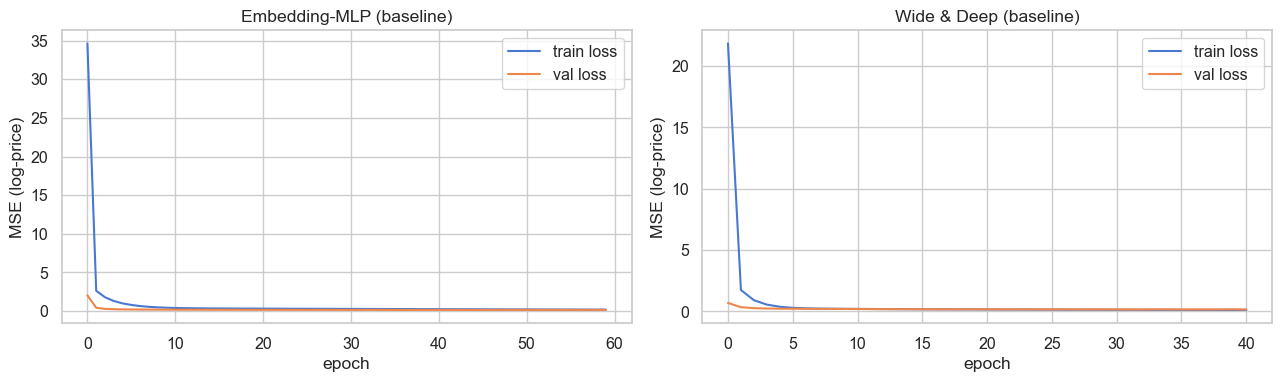

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, title in [
        (axes[0], hist_mlp_base, 'Embedding-MLP (baseline)'),
        (axes[1], hist_wd_base,  'Wide & Deep (baseline)')]:
    ax.plot(hist.history['loss'], label='train loss')
    ax.plot(hist.history['val_loss'], label='val loss')
    ax.set_title(title); ax.set_xlabel('epoch'); ax.set_ylabel('MSE (log-price)')
    ax.legend()
plt.tight_layout(); plt.show()

### 6.2 Baseline comparison — Embedding-MLP vs Wide & Deep

Both baselines use the same features, split and metrics, so this is the like-for-like comparison
that decides which architecture starts ahead **before** any tuning happens. The table adds the
epochs each model actually ran (EarlyStopping restores the best weights, so this is not always
`MAX_EPOCHS`) and its best validation loss, since a model can reach a similar test MAE by very
different training paths.

BASELINE TEST-SET PERFORMANCE (before tuning)


,MAE,RMSE,MAPE,R2,epochs,best val loss,params
MLP (baseline),"$2,805","$4,602",33.4%,0.8400,60,0.1533,"41,391"
Wide&Deep (baseline),"$2,827","$4,586",33.9%,0.8411,41,0.1566,"169,240"



Head-to-head:
  MAE            -> MLP (baseline)         better by 0.8%
  RMSE           -> Wide&Deep (baseline)   better by 0.3%
  MAPE           -> MLP (baseline)         better by 1.6%
  R2             -> Wide&Deep (baseline)   better by 0.1%
  best val loss  -> MLP (baseline)         better by 2.1%


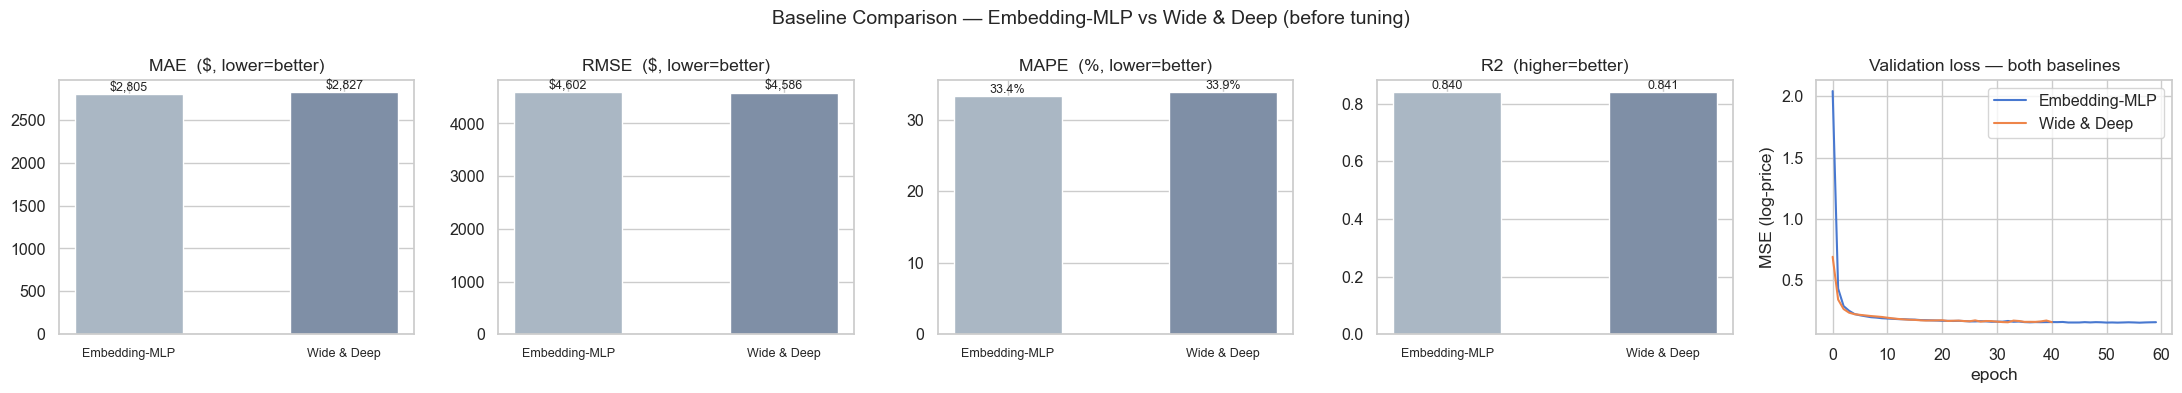

Better baseline by R2: Wide&Deep (baseline) (R2 0.8411, MAE $2,827) — this is the reference both models are tuned against in Task 2.


In [22]:
baseline_names = ['MLP (baseline)', 'Wide&Deep (baseline)']
baseline_hists = {'MLP (baseline)': hist_mlp_base, 'Wide&Deep (baseline)': hist_wd_base}

base_comp = pd.DataFrame({n: results[n] for n in baseline_names}).T[['MAE', 'RMSE', 'MAPE', 'R2']]
base_comp['epochs']       = [len(baseline_hists[n].history['loss']) for n in baseline_names]
base_comp['best val loss'] = [min(baseline_hists[n].history['val_loss']) for n in baseline_names]
base_comp['params']        = [mlp_base.count_params(), wd_base.count_params()]

base_display = base_comp.copy()
base_display['MAE']           = base_display['MAE'].map('${:,.0f}'.format)
base_display['RMSE']          = base_display['RMSE'].map('${:,.0f}'.format)
base_display['MAPE']          = base_display['MAPE'].map('{:.1f}%'.format)
base_display['R2']            = base_display['R2'].map('{:.4f}'.format)
base_display['best val loss'] = base_display['best val loss'].map('{:.4f}'.format)
base_display['params']        = base_display['params'].map('{:,}'.format)
print('BASELINE TEST-SET PERFORMANCE (before tuning)'); print('=' * 78)
display(base_display)

# Which baseline wins on each metric, and by how much
lower_better = ['MAE', 'RMSE', 'MAPE', 'best val loss']
print('\nHead-to-head:')
for metric in ['MAE', 'RMSE', 'MAPE', 'R2', 'best val loss']:
    a, b = base_comp.loc[baseline_names[0], metric], base_comp.loc[baseline_names[1], metric]
    winner = baseline_names[0] if ((a < b) == (metric in lower_better)) else baseline_names[1]
    gap = abs(a - b) / max(abs(a), abs(b)) * 100
    print(f'  {metric:14s} -> {winner:22s} better by {gap:.1f}%')

# Same metrics side by side, plus the two validation curves on one axis
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
x = np.arange(len(baseline_names)); w = 0.5
short = ['Embedding-MLP', 'Wide & Deep']
titles = {'MAE': '  ($, lower=better)', 'RMSE': '  ($, lower=better)',
          'MAPE': '  (%, lower=better)', 'R2': '  (higher=better)'}
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE', 'R2']):
    vals = [base_comp.loc[n, metric] for n in baseline_names]
    ax.bar(x, vals, w, color=['#aab7c4', '#7f8fa6'])
    ax.set_xticks(x); ax.set_xticklabels(short, fontsize=9)
    ax.set_title(metric + titles[metric])
    fmt = '{:.3f}' if metric == 'R2' else ('{:.1f}%' if metric == 'MAPE' else '${:,.0f}')
    for i, v in enumerate(vals):
        ax.text(i, v, fmt.format(v), ha='center', va='bottom', fontsize=9)

for n, label in zip(baseline_names, short):
    axes[4].plot(baseline_hists[n].history['val_loss'], label=label)
axes[4].set_title('Validation loss — both baselines')
axes[4].set_xlabel('epoch'); axes[4].set_ylabel('MSE (log-price)')
axes[4].legend()

fig.suptitle('Baseline Comparison — Embedding-MLP vs Wide & Deep (before tuning)', fontsize=14)
plt.tight_layout(); plt.show()

better_baseline = base_comp['R2'].idxmax()
print(f'Better baseline by R2: {better_baseline} '
      f'(R2 {base_comp.loc[better_baseline, "R2"]:.4f}, '
      f'MAE ${base_comp.loc[better_baseline, "MAE"]:,.0f}) — '
      f'this is the reference both models are tuned against in Task 2.')

## 7. Task 2 — Hyperparameter Tuning with Keras Tuner



### Optimisation technique

I used **Hyperband** instead of plain `RandomSearch` as it gives a lot of
configurations for a small epoch budget, drops the weak ones early, and spends the saved compute
training the survivors closer to the full `MAX_EPOCHS`.


In [13]:
# Search space for each model
def mlp_hypermodel(hp):
    return build_embedding_mlp(
        units=hp.Choice('units', [64, 128, 256]),
        n_layers=hp.Int('n_layers', 1, 3),
        dropout=hp.Choice('dropout', [0.1, 0.2, 0.3, 0.4]),
        learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4]),
        emb_factor=hp.Choice('emb_factor', [0.25, 0.5]))

def wide_deep_hypermodel(hp):
    return build_wide_deep(
        units=hp.Choice('units', [128, 256, 384]),
        n_layers=hp.Int('n_layers', 2, 4),
        dropout=hp.Choice('dropout', [0.2, 0.3, 0.4]),
        learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4]),
        emb_factor=hp.Choice('emb_factor', [0.25, 0.5]))

### 7.1 Tune Model 1 — Embedding-MLP

In [14]:
tuner_mlp = kt.Hyperband(
    mlp_hypermodel,
    objective='val_loss',
    max_epochs=MAX_EPOCHS,
    factor=3,
    seed=SEED,
    overwrite=True,
    directory='kt_dir', project_name='mlp')

tuner_mlp.search(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    batch_size=BATCH_SIZE,
    callbacks=[early_stop(patience=5)], verbose=0)

best_hp_mlp = tuner_mlp.get_best_hyperparameters(1)[0]
print('Best Embedding-MLP hyperparameters:')
print(json.dumps(best_hp_mlp.values, indent=2))



Best Embedding-MLP hyperparameters:
{
  "units": 256,
  "n_layers": 3,
  "dropout": 0.3,
  "learning_rate": 0.001,
  "emb_factor": 0.25,
  "tuner/epochs": 60,
  "tuner/initial_epoch": 20,
  "tuner/bracket": 1,
  "tuner/round": 1,
  "tuner/trial_id": "0074"
}


In [15]:
# Retrain the best config for the full epoch budget. Hyperband adds its own 'tuner/...' entries to
# hp.values, so they are stripped out before the real hyperparameters go into the builder.
best_cfg_mlp = {k: v for k, v in best_hp_mlp.values.items() if not k.startswith('tuner/')}
print('Retraining MLP with:', best_cfg_mlp)

mlp_tuned = build_embedding_mlp(**best_cfg_mlp)
hist_mlp_tuned = mlp_tuned.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop()], verbose=0)
results['MLP (tuned)'] = evaluate_model(
    mlp_tuned, test_inputs, y_test, 'MLP (tuned) — TEST')

Retraining MLP with: {'units': 256, 'n_layers': 3, 'dropout': 0.3, 'learning_rate': 0.001, 'emb_factor': 0.25}
MLP (tuned) — TEST               | MAE $    2,851 | RMSE $    4,687 | MAPE  35.0% | R2 0.8340


### 7.2 Tune Model 2 — Wide & Deep

In [16]:
tuner_wd = kt.Hyperband(
    wide_deep_hypermodel,
    objective='val_loss',
    max_epochs=MAX_EPOCHS,
    factor=3,
    seed=SEED,
    overwrite=True,
    directory='kt_dir', project_name='wide_deep')

tuner_wd.search(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    batch_size=BATCH_SIZE,
    callbacks=[early_stop(patience=5)], verbose=0)

best_hp_wd = tuner_wd.get_best_hyperparameters(1)[0]
print('Best Wide & Deep hyperparameters:')
print(json.dumps(best_hp_wd.values, indent=2))


Best Wide & Deep hyperparameters:
{
  "units": 256,
  "n_layers": 2,
  "dropout": 0.3,
  "learning_rate": 0.001,
  "emb_factor": 0.5,
  "tuner/epochs": 60,
  "tuner/initial_epoch": 20,
  "tuner/bracket": 3,
  "tuner/round": 3,
  "tuner/trial_id": "0047"
}


In [17]:
# Same 'tuner/*' strip as for the MLP above
best_cfg_wd = {k: v for k, v in best_hp_wd.values.items() if not k.startswith('tuner/')}
print('Retraining Wide&Deep with:', best_cfg_wd)

wd_tuned = build_wide_deep(**best_cfg_wd)
hist_wd_tuned = wd_tuned.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop()], verbose=0)
results['Wide&Deep (tuned)'] = evaluate_model(
    wd_tuned, test_inputs, y_test, 'Wide&Deep (tuned) — TEST')

Retraining Wide&Deep with: {'units': 256, 'n_layers': 2, 'dropout': 0.3, 'learning_rate': 0.001, 'emb_factor': 0.5}
Wide&Deep (tuned) — TEST         | MAE $    2,808 | RMSE $    4,567 | MAPE  33.6% | R2 0.8424


## 8. Task 3 — Evaluation & Before/After-Tuning Comparison



In [18]:
comp = pd.DataFrame(results).T[['MAE', 'RMSE', 'MAPE', 'R2']]
comp = comp.loc[['MLP (baseline)', 'MLP (tuned)',
                 'Wide&Deep (baseline)', 'Wide&Deep (tuned)']]
comp_display = comp.copy()
comp_display['MAE']  = comp_display['MAE'].map('${:,.0f}'.format)
comp_display['RMSE'] = comp_display['RMSE'].map('${:,.0f}'.format)
comp_display['MAPE'] = comp_display['MAPE'].map('{:.1f}%'.format)
comp_display['R2']   = comp_display['R2'].map('{:.4f}'.format)
print('TEST-SET PERFORMANCE'); print('=' * 64)
comp_display


TEST-SET PERFORMANCE


,MAE,RMSE,MAPE,R2
MLP (baseline),"$2,805","$4,602",33.4%,0.8400
MLP (tuned),"$2,851","$4,687",35.0%,0.8340
Wide&Deep (baseline),"$2,827","$4,586",33.9%,0.8411
Wide&Deep (tuned),"$2,808","$4,567",33.6%,0.8424


### 8.1 Before vs after tuning — improvement summary
Positive values mean tuning **reduced error** (MAE/RMSE) or **increased** explained variance (R²).

In [19]:
def pct(before, after):  # signed % change
    return (after - before) / before * 100

summary = pd.DataFrame({
    'MLP':       {
        'MAE  ($)  before→after': f"{comp.loc['MLP (baseline)','MAE']:,.0f} → {comp.loc['MLP (tuned)','MAE']:,.0f}",
        'RMSE ($)  before→after': f"{comp.loc['MLP (baseline)','RMSE']:,.0f} → {comp.loc['MLP (tuned)','RMSE']:,.0f}",
        'R2        before→after': f"{comp.loc['MLP (baseline)','R2']:.4f} → {comp.loc['MLP (tuned)','R2']:.4f}",
        'MAE reduction (%)':      f"{-pct(comp.loc['MLP (baseline)','MAE'], comp.loc['MLP (tuned)','MAE']):.1f}%",
        'R2 gain (abs)':          f"{comp.loc['MLP (tuned)','R2'] - comp.loc['MLP (baseline)','R2']:+.4f}",
    },
    'Wide&Deep': {
        'MAE  ($)  before→after': f"{comp.loc['Wide&Deep (baseline)','MAE']:,.0f} → {comp.loc['Wide&Deep (tuned)','MAE']:,.0f}",
        'RMSE ($)  before→after': f"{comp.loc['Wide&Deep (baseline)','RMSE']:,.0f} → {comp.loc['Wide&Deep (tuned)','RMSE']:,.0f}",
        'R2        before→after': f"{comp.loc['Wide&Deep (baseline)','R2']:.4f} → {comp.loc['Wide&Deep (tuned)','R2']:.4f}",
        'MAE reduction (%)':      f"{-pct(comp.loc['Wide&Deep (baseline)','MAE'], comp.loc['Wide&Deep (tuned)','MAE']):.1f}%",
        'R2 gain (abs)':          f"{comp.loc['Wide&Deep (tuned)','R2'] - comp.loc['Wide&Deep (baseline)','R2']:+.4f}",
    },
}).T
summary

,MAE ($) before→after,RMSE ($) before→after,R2 before→after,MAE reduction (%),R2 gain (abs)
MLP,"2,805 → 2,851","4,602 → 4,687",0.8400 → 0.8340,-1.7%,-0.0059
Wide&Deep,"2,827 → 2,808","4,586 → 4,567",0.8411 → 0.8424,0.7%,+0.0013


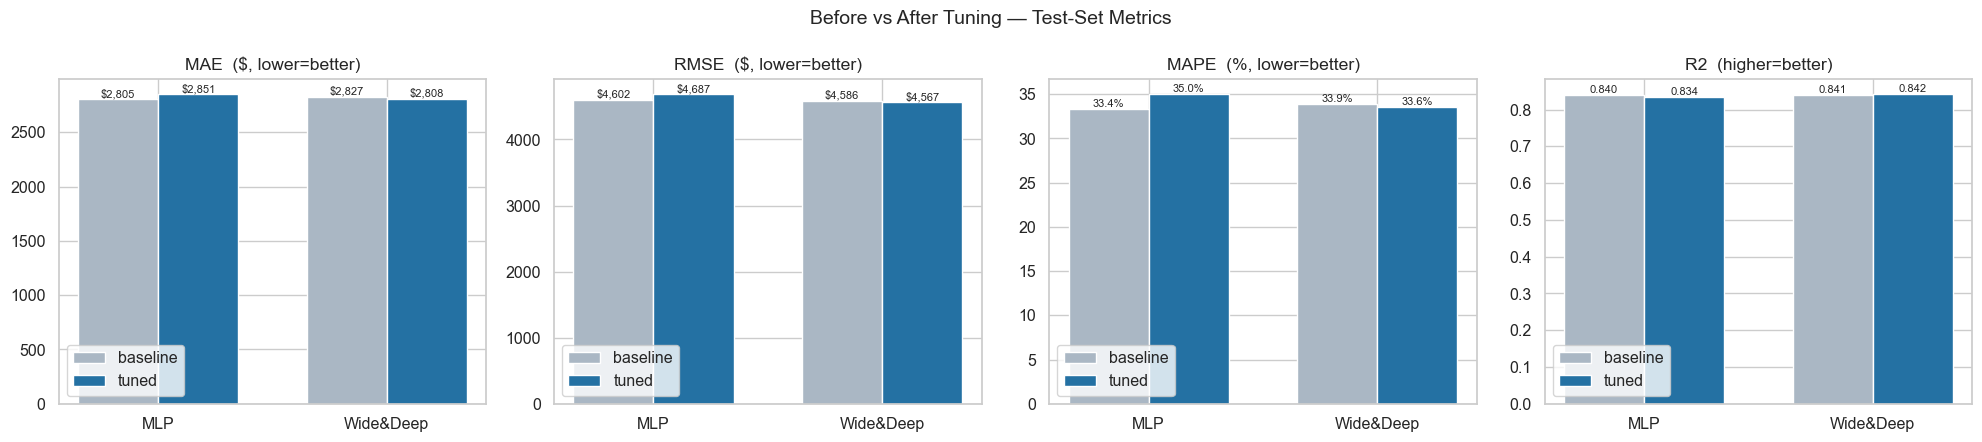

In [20]:
# Bar charts comparing baseline and tuned for each metric
models = ['MLP', 'Wide&Deep']
metrics = ['MAE', 'RMSE', 'MAPE', 'R2']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
x = np.arange(len(models)); w = 0.35
titles = {'MAE': '  ($, lower=better)', 'RMSE': '  ($, lower=better)',
          'MAPE': '  (%, lower=better)', 'R2': '  (higher=better)'}
for ax, metric in zip(axes, metrics):
    base_vals  = [comp.loc[f'{m} (baseline)', metric] for m in models]
    tuned_vals = [comp.loc[f'{m} (tuned)',    metric] for m in models]
    ax.bar(x - w/2, base_vals, w, label='baseline', color='#aab7c4')
    ax.bar(x + w/2, tuned_vals, w, label='tuned',    color='#2471a3')
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_title(metric + titles[metric])
    ax.legend()
    for i, (b, t) in enumerate(zip(base_vals, tuned_vals)):
        if metric == 'R2':
            fmt = '{:.3f}'
        elif metric == 'MAPE':
            fmt = '{:.1f}%'
        else:
            fmt = '${:,.0f}'
        ax.text(i - w/2, b, fmt.format(b), ha='center', va='bottom', fontsize=8)
        ax.text(i + w/2, t, fmt.format(t), ha='center', va='bottom', fontsize=8)
fig.suptitle('Before vs After Tuning — Test-Set Metrics', fontsize=14)
plt.tight_layout(); plt.show()

### 8.2 Predicted vs actual price (best model)


Best model by R2: Wide&Deep (tuned)


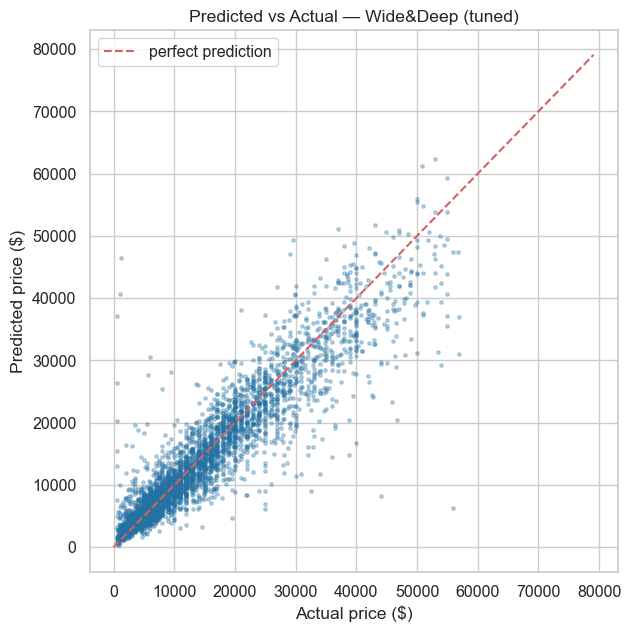

In [21]:
# Pick the best model by R2
best_name = comp['R2'].idxmax()
best_model = {'MLP (baseline)': mlp_base, 'MLP (tuned)': mlp_tuned,
              'Wide&Deep (baseline)': wd_base, 'Wide&Deep (tuned)': wd_tuned}[best_name]
print(f'Best model by R2: {best_name}')

pred = np.expm1(best_model.predict(test_inputs, verbose=0).ravel())
truth = np.expm1(y_test)
idx = np.random.choice(len(truth), size=min(4000, len(truth)), replace=False)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(truth[idx], pred[idx], s=6, alpha=0.3, color='#2471a3')
lim = [0, max(truth.max(), pred.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='perfect prediction')
ax.set_xlabel('Actual price ($)'); ax.set_ylabel('Predicted price ($)')
ax.set_title(f'Predicted vs Actual — {best_name}')
ax.legend(); plt.tight_layout(); plt.show()